# SpaceTime: Causal Discovery from Non-stationary Time Series

Tutorial of SpaceTime,

1. how to simulate several time-series contexts with a shared regime change,
2. how to run SpaceTime with known changepoints,
3. how to run SpaceTime with detected changepoints.


In [114]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from causalchange.causal_change import CausalChange
from causalchange.config.cc_config import ChangepointMode
from causalchange.config.cc_types import (
    ContextAggregation,
    DataMode,
    GPType,
    GraphSearch,
    ScoreType,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Synthetic Data Generation


Data generation as

- `x0(t-1) -> x0(t)`, `x1(t-1) -> x1(t)`, `x2(t-1) -> x2(t)`

- `x0(t-1) -> x1(t)`, `x1(t-1) -> x2(t)`


- after the changepoint, the coefficient from `x0[t-1]` to `x1[t]` changes.

In [115]:
def simulate_spacetime_contexts(
    n: int = 160,
    changepoint: int = 80,
    contexts: tuple[str, ...] = ("A", "B"),
    seed: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    frames = []

    for context in contexts:
        x0 = np.zeros(n)
        x1 = np.zeros(n)
        x2 = np.zeros(n)

        for t in range(1, n):
            x0[t] = 0.6 * x0[t - 1] + rng.normal(scale=0.35)

            if t < changepoint:
                x1[t] = 0.5 * x1[t - 1] + 1.1 * x0[t - 1] + rng.normal(scale=0.25)
            else:
                x1[t] = 0.5 * x1[t - 1] + 0.2 * x0[t - 1] + rng.normal(scale=0.90)

            x2[t] = 0.5 * x2[t - 1] + 0.8 * x1[t - 1] + rng.normal(scale=0.35)

        frames.append(
            pd.DataFrame(
                {
                    "context": context,
                    "x0": x0,
                    "x1": x1,
                    "x2": x2,
                }
            )
        )

    return pd.concat(frames, axis=0, ignore_index=True)

In [116]:
true_changepoint = 80

X = simulate_spacetime_contexts(
    n=160,
    changepoint=true_changepoint,
    contexts=("A", "B"),
    seed=42,
)

X.head()

,context,x0,x1,x2
0,A,0.000000,0.000000,0.000000
1,A,0.106651,-0.259996,0.262658
2,A,0.393188,-0.500441,-0.532431
3,A,0.280657,0.103226,-0.672448
4,A,-0.130171,0.580185,0.018584




Plots

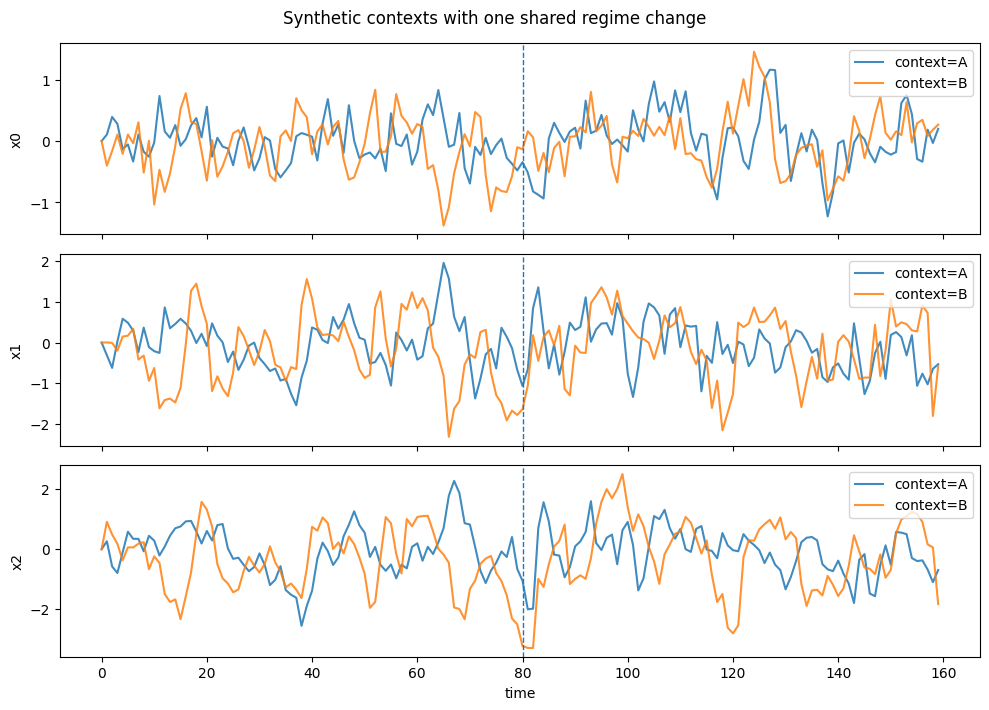

In [72]:
def plot_panel_timeseries(X: pd.DataFrame, *, changepoints=None, title=None):
    changepoints = list(changepoints or [])
    variables = [c for c in X.columns if c != "context"]
    contexts = list(X["context"].unique())

    fig, axes = plt.subplots(
        len(variables),
        1,
        figsize=(10, 2.4 * len(variables)),
        sharex=True,
    )

    if len(variables) == 1:
        axes = [axes]

    for ax, variable in zip(axes, variables, strict=False):
        for context in contexts:
            values = X.loc[X["context"] == context, variable].to_numpy()
            ax.plot(values, label=f"context={context}", alpha=0.85)

        for cp in changepoints:
            ax.axvline(cp, linestyle="--", linewidth=1)

        ax.set_ylabel(variable)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("time")
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    plt.show()


plot_panel_timeseries(
    X,
    changepoints=[true_changepoint],
    title="Synthetic contexts with one shared regime change",
)

## 2. SpaceTime with known changepoints

`ChangepointMode.FIXED` tells SpaceTime where the regime boundaries are.  
This is useful when changepoints are known from domain knowledge or an external detector.

In [95]:
cc_fixed = CausalChange(
    data_mode=DataMode.TIME_CONTEXTS,
    graph_search=GraphSearch.GLOBE,
    score_type=ScoreType.LIN,
    aggregation=ContextAggregation.SKIP,
    context_col="context",
    tau_max=2,
    detect_contexts=True,
    detect_regimes=True,
    changepoints=ChangepointMode.FIXED,
    fixed_changepoints=[true_changepoint],
)

cc_fixed.fit(X)

instantaneous_edges = [edge for edge in cc_fixed.graph_.edges if edge[0][1] == 0 and edge[1][1] == 0]

lagged_edges = [edge for edge in cc_fixed.graph_.edges if edge[0][1] > 0 and edge[1][1] == 0]

print("Fixed changepoints:", cc_fixed.result_.changepoints)
print("Instantaneous edges:")
for edge in instantaneous_edges:
    print("  ", edge)

print("Lagged edges:")
for edge in lagged_edges:
    print("  ", edge)

Fixed changepoints: [80]
Instantaneous edges:
Lagged edges:
   (('x0', 1), ('x1', 0))
   (('x0', 1), ('x0', 0))
   (('x1', 1), ('x2', 0))
   (('x1', 1), ('x1', 0))
   (('x2', 1), ('x2', 0))


In [98]:
def edge_recovery_summary(estimated_edges, true_edges):
    estimated_edges = set(estimated_edges)
    true_edges = set(true_edges)

    tp = estimated_edges & true_edges
    fp = estimated_edges - true_edges
    fn = true_edges - estimated_edges

    precision = len(tp) / max(len(tp) + len(fp), 1)
    recall = len(tp) / max(len(tp) + len(fn), 1)

    return {
        "precision": precision,
        "recall": recall,
        "true_positives": sorted(tp),
        "false_positives": sorted(fp),
        "false_negatives": sorted(fn),
    }


lagged_edges = {edge for edge in cc_fixed.graph_.edges if edge[0][1] > 0 and edge[1][1] == 0}
expected_graph = {
    (("x0", 1), ("x0", 0)),
    (("x1", 1), ("x1", 0)),
    (("x2", 1), ("x2", 0)),
    (("x0", 1), ("x1", 0)),
    (("x1", 1), ("x2", 0)),
}


def changepoint_error(detected, true_changepoint):
    if not detected:
        return None
    return min(abs(cp - true_changepoint) for cp in detected)


expected_contexts = {
    "x0": {"A": 0, "B": 0},
    "x1": {"A": 0, "B": 0},
    "x2": {"A": 0, "B": 0},
}

expected_regimes = {
    "x0": {0: 0, 1: 0},  # stationary mechanism
    "x1": {0: 0, 1: 1},  # direct mechanism change
}

In [105]:
print("Context partitions:")
print(cc_fixed.result_.partitions.contexts)

print("\nRegime partitions:")
print(cc_fixed.result_.partitions.regimes)
pd.DataFrame(cc_fixed.result_.partitions.diagnostics["tests"])
# print("\nPartition diagnostics:")
# print(cc_fixed.result_.partitions.diagnostics)

Context partitions:
{'x0': {'A': 0, 'B': 0}, 'x1': {'A': 0, 'B': 0}, 'x2': {'A': 0, 'B': 0}}

Regime partitions:
{'x0': {0: 0, 1: 0}, 'x1': {0: 0, 1: 1}, 'x2': {0: 0, 1: 0}}


,kind,target,regime_a,regime_b,pvalue,same,method,context_a,context_b,regime
0,regime,x0,0.0,1.0,0.735183,True,kci,NaN,NaN,NaN
1,regime,x1,0.0,1.0,0.000008,False,kci,NaN,NaN,NaN
2,regime,x2,0.0,1.0,0.122807,True,kci,NaN,NaN,NaN
3,context,x0,NaN,NaN,0.176536,True,kci,A,B,0.0
4,context,x0,NaN,NaN,0.931504,True,kci,A,B,1.0
5,context,x1,NaN,NaN,0.749188,True,kci,A,B,0.0
6,context,x1,NaN,NaN,0.471097,True,kci,A,B,1.0
7,context,x2,NaN,NaN,0.446066,True,kci,A,B,0.0
8,context,x2,NaN,NaN,0.271130,True,kci,A,B,1.0


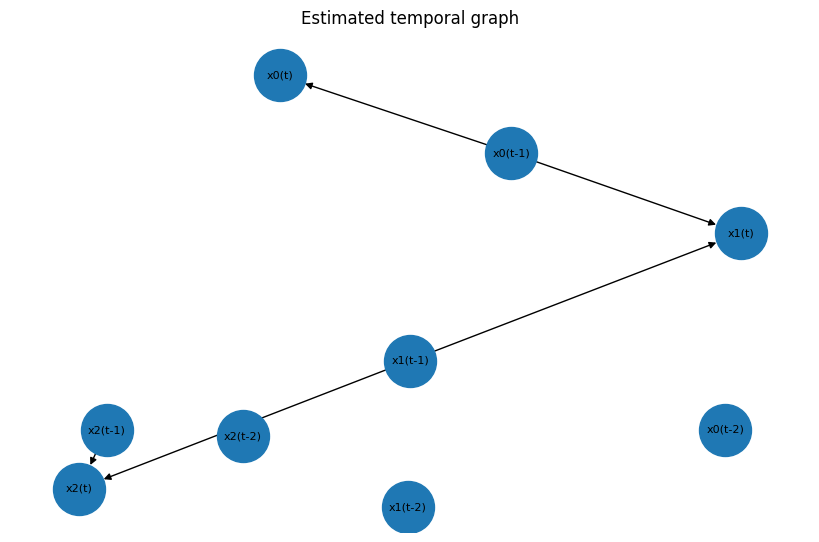

{'precision': 1.0, 'recall': 1.0, 'true_positives': [(('x0', 1), ('x0', 0)), (('x0', 1), ('x1', 0)), (('x1', 1), ('x1', 0)), (('x1', 1), ('x2', 0)), (('x2', 1), ('x2', 0))], 'false_positives': [], 'false_negatives': []}


In [112]:
def temporal_node_label(node):
    var, lag = node
    return f"{var}(t)" if lag == 0 else f"{var}(t-{lag})"


plt.figure(figsize=(8, 5))
pos = nx.spring_layout(cc_fixed.graph_, seed=42)
nx.draw(
    cc_fixed.graph_,
    pos=pos,
    labels={node: temporal_node_label(node) for node in cc_fixed.graph_.nodes},
    with_labels=True,
    node_size=1400,
    font_size=8,
)
plt.title("Estimated temporal graph")
plt.show()
print(edge_recovery_summary(lagged_edges, expected_graph))

## 3. SpaceTime with changepoint detection

Use `ChangepointMode.DETECT` for changepoint detection in time.
For multiple contexts, the detector combines residuals across contexts.

In [113]:
cc_detect = CausalChange(
    data_mode=DataMode.TIME_CONTEXTS,
    graph_search=GraphSearch.GLOBE,
    score_type=ScoreType.LIN,
    aggregation=ContextAggregation.SKIP,
    context_col="context",
    tau_max=2,
    changepoints=ChangepointMode.DETECT,
    d_min=20,
    max_iter=3,
    pelt_penalty=2.0,  # might req some tuning
)

cc_detect.fit(X)

print("Detected changepoints:", cc_detect.result_.changepoints)
print("Edges:")
for edge in sorted(cc_detect.graph_.edges()):
    print("  ", edge)

print("Detected changepoints:", cc_detect.result_.changepoints)
print("Closest changepoint error:", changepoint_error(cc_detect.result_.changepoints, true_changepoint))

Detected changepoints: [64]
Edges:
   (('x0', 1), ('x0', 0))
   (('x0', 1), ('x1', 0))
   (('x1', 1), ('x1', 0))
   (('x1', 1), ('x2', 0))
   (('x2', 1), ('x2', 0))
Detected changepoints: [64]
Closest changepoint error: 16


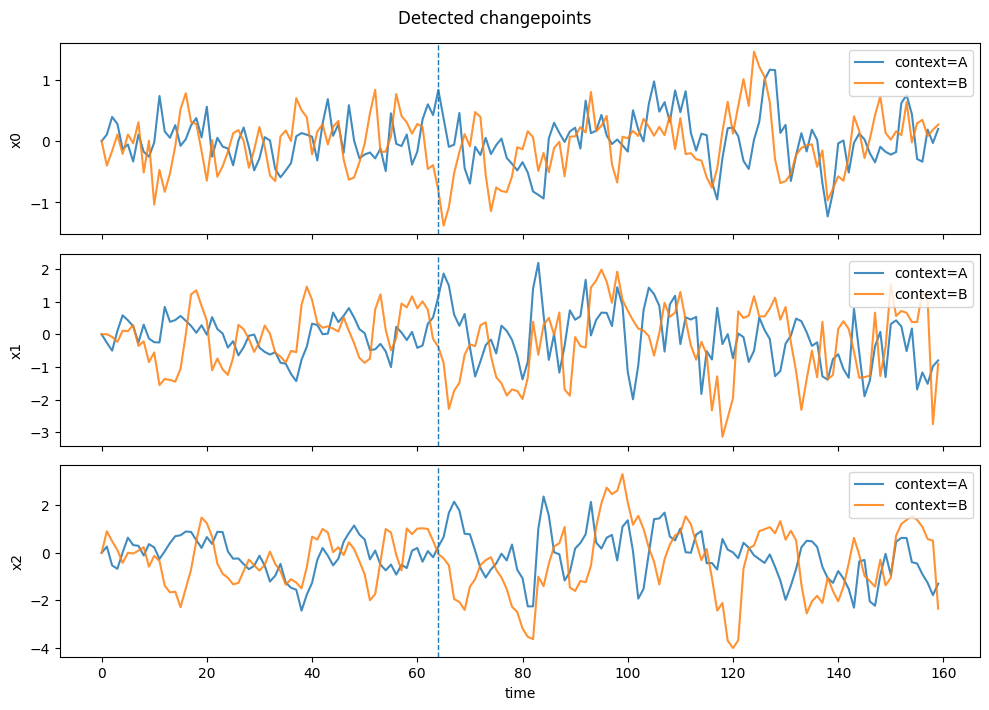

In [107]:
plot_panel_timeseries(
    X,
    changepoints=cc_detect.result_.changepoints,
    title="Detected changepoints",
)

In [108]:
summary = pd.DataFrame(
    [
        {
            "run": "fixed",
            "changepoints": cc_fixed.result_.changepoints,
            "n_edges": cc_fixed.graph_.number_of_edges(),
        },
        {
            "run": "detected",
            "changepoints": cc_detect.result_.changepoints,
            "n_edges": cc_detect.graph_.number_of_edges(),
        },
    ]
)

summary

,run,changepoints,n_edges
0,fixed,[80],5
1,detected,[64],5


## 4. Parameters

**Partitioning** Set `detect_contexts=False` and `detect_regimes=False` if you want to skip the kernel testing
on whether causal mechanisms are shared across contexts and regimes, as this can be expensive.


In [67]:
cc_partitioned = CausalChange(
    data_mode=DataMode.TIME_CONTEXTS,
    graph_search=GraphSearch.GLOBE,
    score_type=ScoreType.LIN,
    aggregation=ContextAggregation.SKIP,
    context_col="context",
    tau_max=2,
    changepoints=ChangepointMode.FIXED,
    fixed_changepoints=[true_changepoint],
    detect_contexts=False,
    detect_regimes=False,
    mechanism_test_alpha=0.05,
)

cc_partitioned.fit(X)

print("Context partitions:")
print(cc_partitioned.result_.partitions.contexts)

print("\nRegime partitions:")
print(cc_partitioned.result_.partitions.regimes)

print("\nNumber of mechanism tests:")
print(len(cc_partitioned.result_.partitions.diagnostics.get("tests", [])))

Context partitions:
{'x0': {'A': 0, 'B': 0}, 'x1': {'A': 0, 'B': 0}, 'x2': {'A': 0, 'B': 0}}

Regime partitions:
{'x0': {0: 0, 1: 1}, 'x1': {0: 0, 1: 1}, 'x2': {0: 0, 1: 1}}

Number of mechanism tests:
0



**Scoring** The fast examples above use `ScoreType.LIN`. For nonlinear MDL scoring use

- `score_type=GPType.EXACT` for exact GP-MDL,
- `score_type=GPType.FOURIER` for a random Fourier feature approximation.

(These are slower, so this cell uses fewer restarts and disables refinement)

In [68]:
cc_rff = CausalChange(
    data_mode=DataMode.TIME_CONTEXTS,
    graph_search=GraphSearch.GLOBE,
    score_type=GPType.FOURIER,
    aggregation=ContextAggregation.SKIP,
    context_col="context",
    tau_max=2,
    changepoints=ChangepointMode.FIXED,
    fixed_changepoints=[true_changepoint],
    score_kwargs={
        "D": 64,
        "restarts": 2,
        "refine": False,
        "seed": 42,
    },
)

cc_rff.fit(X)

print("RFF edges:")
for edge in sorted(cc_rff.graph_.edges()):
    print("  ", edge)

RFF edges:
   (('x0', 1), ('x0', 0))
   (('x0', 1), ('x1', 0))
   (('x1', 1), ('x1', 0))
   (('x1', 1), ('x2', 0))
   (('x2', 1), ('x2', 0))
